# 02 - Support Vector Machine (SVM)
## Explainable Machine Learning for Breast Cancer Risk Prediction

Notebook ini **mandiri** (bisa dijalankan sendiri tanpa bergantung ke notebook lain) dan berfokus khusus pada satu algoritma: **Support Vector Machine (SVM)**.

Alur: Load Data -> Preprocessing -> Training + Hyperparameter Tuning -> Evaluasi -> Explainable AI (SHAP) -> Simpan hasil metrik ke `results_svm.csv` untuk dibandingkan di `05_Model_Comparison.ipynb`.


## 1. Import Library

In [3]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Library dasar berhasil diimpor.')

from sklearn.svm import SVC
import shap


Library dasar berhasil diimpor.


## 2. Load Data & Preprocessing

In [4]:

df = pd.read_csv('data/breast-cancer.csv')
df = df.drop(columns=['id'])

le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # B=0, M=1
print('Mapping label:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
df.head()


Mapping label: {'B': 0, 'M': 1}
Train shape: (455, 30) | Test shape: (114, 30)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_encoded
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Fungsi Bantu Evaluasi

In [5]:

def evaluate_model(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }
    return metrics, y_pred, y_proba

def plot_confusion_and_roc(y_te, y_pred, y_proba, model_name, color='#3B7DD8'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)
    axes[0].set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    axes[0].set_xlabel('Prediksi')
    axes[0].set_ylabel('Aktual')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    axes[1].plot(fpr, tpr, color=color, linewidth=2.2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Kurva ROC - {model_name}', fontweight='bold')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()


## 4. Training & Hyperparameter Tuning - SVM

SVM sensitif terhadap skala fitur sehingga kita gunakan `X_train_scaled` / `X_test_scaled`.


In [7]:

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE),
                         svm_param_grid, cv=cv, scoring='roc_auc', n_jobs=1)
svm_grid.fit(X_train_scaled, y_train)

model = svm_grid.best_estimator_
print('Best SVM params:', svm_grid.best_params_)
print('Best CV ROC-AUC:', round(svm_grid.best_score_, 4))


Best SVM params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV ROC-AUC: 0.9954


## 5. Evaluasi Model - SVM

In [8]:

metrics, y_pred, y_proba = evaluate_model(model, X_test_scaled, y_test, 'SVM')
metrics_df = pd.DataFrame([metrics]).set_index('Model').round(4)
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.9825,1.0,0.9524,0.9756,0.996


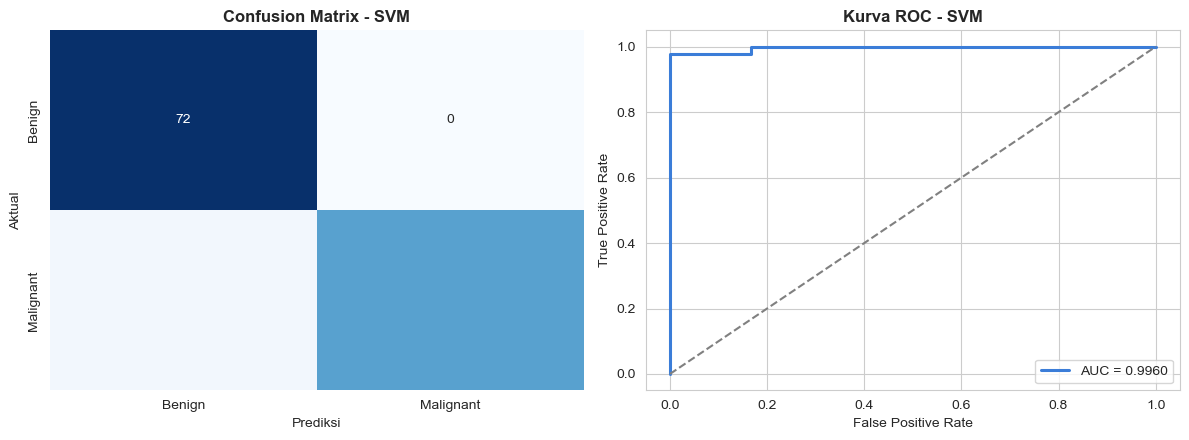

In [9]:

plot_confusion_and_roc(y_test, y_pred, y_proba, 'SVM', color='#3B7DD8')


In [10]:

print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6. Simpan Hasil Metrik (results_svm.csv)

In [11]:

metrics_df.to_csv('results_svm.csv')
print('Hasil metrik disimpan ke results_svm.csv')
metrics_df


Hasil metrik disimpan ke results_svm.csv


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.9825,1.0,0.9524,0.9756,0.996


## 7. Explainable AI (XAI) - SVM

SVM bukan model berbasis pohon, sehingga kita gunakan **SHAP KernelExplainer** (model-agnostic).
Untuk efisiensi komputasi, digunakan sampel data latih sebagai *background* dan sebagian data uji untuk dijelaskan.


  0%|          | 0/60 [00:00<?, ?it/s]

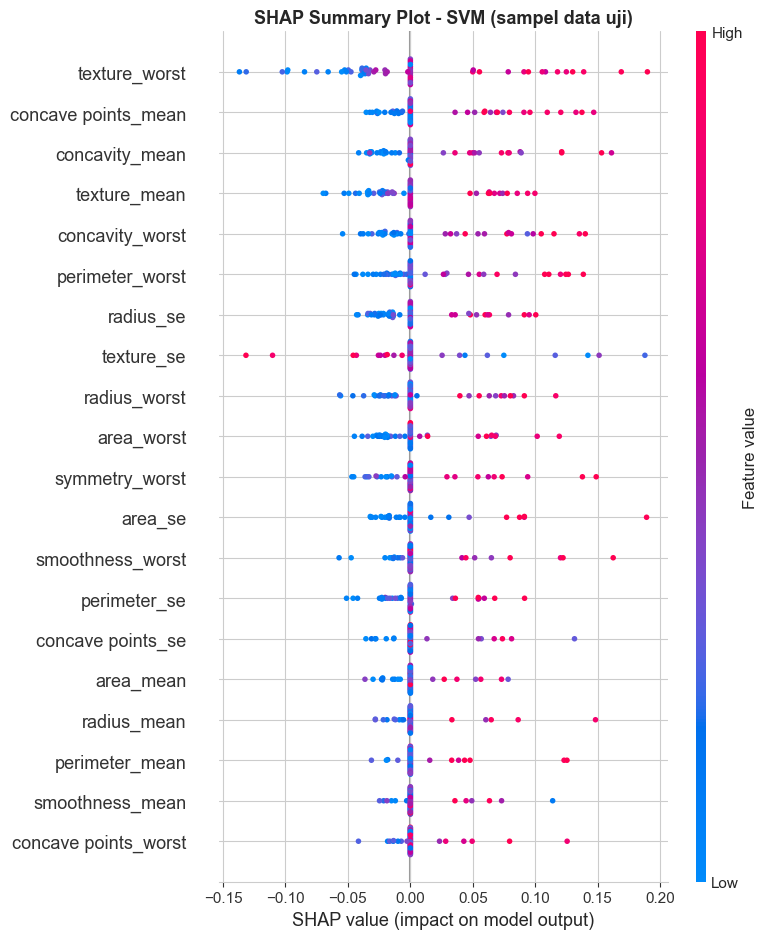

In [12]:

background = shap.sample(X_train_scaled, 50, random_state=RANDOM_STATE)
X_test_sample = X_test_scaled.sample(60, random_state=RANDOM_STATE)

explainer = shap.KernelExplainer(model.predict_proba, background)
shap_values = explainer.shap_values(X_test_sample, nsamples=100)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values_pos, X_test_sample, show=False)
plt.title('SHAP Summary Plot - SVM (sampel data uji)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Kesimpulan Singkat - SVM

- Ringkasan metrik model ini tersimpan di `results_svm.csv` dan akan digabungkan dengan hasil model lain di `05_Model_Comparison.ipynb`.
- Model beserta parameter terbaik hasil `GridSearchCV` ditampilkan pada bagian training di atas.
- Interpretasi SHAP menunjukkan fitur-fitur mana yang paling berkontribusi terhadap prediksi model ini.
